# 04 - Clusterização de Voos

Agrupamento para entender perfis operacionais sem usar o alvo.

In [1]:
# Imports e leitura da amostra processada
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8")
data = pd.read_parquet("../data/processed/flights_sample.parquet")
features = ["MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE"]
X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.shape

(300000, 4)

## 1. Método do cotovelo (leve)

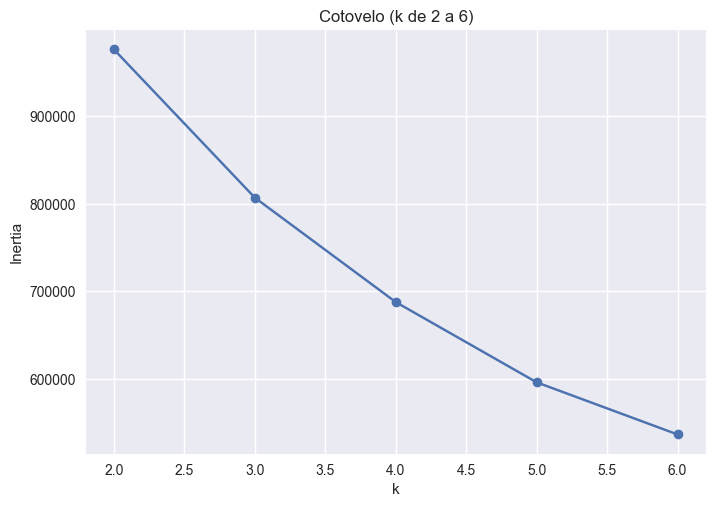

In [2]:
# Metodo do cotovelo: calcula inercia para diferentes k
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(2,7), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Cotovelo (k de 2 a 6)")
plt.show()

## 2. Ajuste final (k=3)

In [3]:
# Ajusta K-Means final com k=3 e anexa clusters aos dados
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
data["CLUSTER"] = clusters

perfil = data.groupby("CLUSTER")[features + ["DELAYED"]].agg({
    "MONTH":"mean",
    "DAY_OF_WEEK":"mean",
    "DEP_HOUR":"mean",
    "DISTANCE":"mean",
    "DELAYED":"mean"
})
print(perfil)

            MONTH  DAY_OF_WEEK   DEP_HOUR     DISTANCE   DELAYED
CLUSTER                                                         
0        6.744551     4.028911  12.967541  1959.378548  0.179760
1        3.506793     3.930980  13.020562   615.653017  0.193934
2        9.498889     3.920003  13.047546   607.292933  0.161428


## 3. Taxa de atraso por cluster

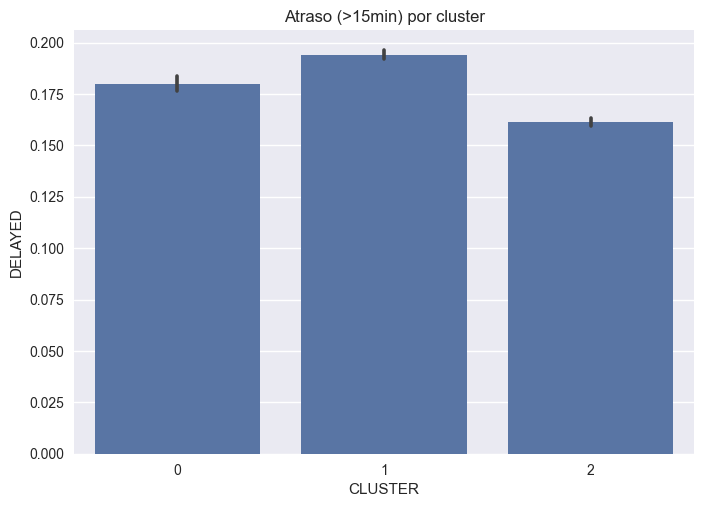

In [4]:
# Visualiza taxa media de atraso por cluster
sns.barplot(data=data, x="CLUSTER", y="DELAYED")
plt.title("Atraso (>15min) por cluster")
plt.show()

### Leituras
- Clusters distinguem horários médios e distâncias.
- Taxas de atraso variam entre grupos, sugerindo perfis operacionais com maior risco mesmo sem usar a variável alvo.